In [ ]:
# Install PyTorch Geometric dependencies
import torch
TORCH_VERSION = torch.__version__.split('+')[0]
CUDA_VERSION = "cpu"  # Colab handles GPU automatically

!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-{TORCH_VERSION}+{CUDA_VERSION}.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-{TORCH_VERSION}+{CUDA_VERSION}.html
!pip install -q torch-cluster -f https://data.pyg.org/whl/torch-{TORCH_VERSION}+{CUDA_VERSION}.html
!pip install -q torch-spline-conv -f https://data.pyg.org/whl/torch-{TORCH_VERSION}+{CUDA_VERSION}.html
!pip install -q torch-geometric


import kagglehub
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv, GCNConv, GINConv, SAGEConv, MessagePassing
from types import SimpleNamespace
from sklearn.metrics import accuracy_score, recall_score, f1_score
import numpy as np
import os

# Download latest version
path = kagglehub.dataset_download("ellipticco/elliptic-data-set")

print("Path to dataset files:", path)

!git clone https://github.com/AbhishiktaGhosh/bitcoin-fraud-detection.git

%cd bitcoin-fraud-detection



# Change directory back to content for data processing
%cd /content

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.4/682.4 kB 14.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 18.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.2/828.2 kB 13.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.9/306.9 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.8 MB/s eta 0:00:00
Using Colab cache for faster access to the 'elliptic-data-set' dataset.
Path to dataset files: /kaggle/input/elliptic-data-set
Cloning into 'bitcoin-fraud-detection'...
remote: Enumerating objects: 115, done.
remote: Counting objects: 100% (115/115), done.
remote: Compressing objects: 100% (77/77), done.
remote: Total 115 (delta 30), reused 111 (delta 26), pack-reused 0 (from 0)
Receiving objects: 100% (115/115), 2.60 MiB | 21.28 MiB/s, done.
Resolving deltas: 100% (30/30), done.
/content/bitcoin-fraud-detection
/co

In [ ]:
!ls


bitcoin-fraud-detection   elliptic_txs_edgelist.csv  sample_data
datasets.py		  elliptic_txs_features.csv  trainer.py
elliptic_txs_classes.csv  models.py


In [ ]:
import pandas as pd
import numpy as np
import networkx as nx

# Load data
edges_df = pd.read_csv("elliptic_txs_edgelist.csv")
features_df = pd.read_csv("elliptic_txs_features.csv", header=None)

# Node IDs
tx_ids = features_df[0].values
node_to_idx = {tx: i for i, tx in enumerate(tx_ids)}
idx_to_node = {i: tx for tx, i in node_to_idx.items()}

In [ ]:
G = nx.DiGraph()   # IMPORTANT: keep direction (fixes major flaw)

edges = []
for u, v in zip(edges_df["txId1"], edges_df["txId2"]):
    if u in node_to_idx and v in node_to_idx:
        ui, vi = node_to_idx[u], node_to_idx[v]
        edges.append((ui, vi))

G.add_edges_from(edges)
print("Nodes:", G.number_of_nodes(), "Edges:", G.number_of_edges())

Nodes: 203769 Edges: 234355


In [ ]:
G.add_nodes_from(range(len(tx_ids)))

In [ ]:
print("Features:", len(tx_ids))
print("Probs:", len(probs))
print("Graph nodes:", G.number_of_nodes())

Features: 203769
Probs: 203768
Graph nodes: 203769


In [ ]:
valid_len = len(probs)

# Restrict graph to only valid nodes
G = G.subgraph(range(valid_len)).copy()

node_probs = {i: probs[i] for i in range(valid_len)}

In [ ]:
missing = set(range(len(tx_ids))) - set(range(len(probs)))
print("Missing node index:", missing)

Missing node index: {203768}


In [ ]:
import numpy as np

probs = np.load("final_probs.npy")

In [ ]:
print("Graph nodes:", G.number_of_nodes())
print("Probs length:", len(probs))

Graph nodes: 203769
Probs length: 203768


In [ ]:
graph_nodes = set(G.nodes())
expected_nodes = set(range(len(probs)))

print("Extra nodes in graph:", graph_nodes - expected_nodes)
print("Missing nodes in graph:", expected_nodes - graph_nodes)

Extra nodes in graph: {203768}
Missing nodes in graph: set()


In [ ]:
probs = np.load("final_probs.npy").astype(float)

valid_nodes = set(G.nodes()).intersection(set(range(len(probs))))

G = G.subgraph(valid_nodes).copy()
node_probs = {i: probs[i] for i in valid_nodes}

assert len(node_probs) == G.number_of_nodes()

print("Using", len(valid_nodes), "nodes out of", len(tx_ids))

Using 203768 nodes out of 203769


In [ ]:
import pandas as pd

edges_df = pd.read_csv("elliptic_txs_edgelist.csv")
edges_df.head()


,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206


In [ ]:
edges = []

for u, v in zip(edges_df["txId1"], edges_df["txId2"]):
    if u in node_to_idx and v in node_to_idx:
        edges.append((node_to_idx[u], node_to_idx[v]))

In [ ]:
features_df = pd.read_csv("elliptic_txs_features.csv", header=None)

tx_ids = features_df[0].values

node_to_idx = {tx_id: idx for idx, tx_id in enumerate(tx_ids)}
idx_to_node = {idx: tx_id for tx_id, idx in node_to_idx.items()}

In [ ]:
edge_list = [
    (node_to_idx[u], node_to_idx[v])
    for u, v in zip(edges_df['txId1'], edges_df['txId2'])
    if u in node_to_idx and v in node_to_idx
]

In [ ]:
import networkx as nx

G = nx.DiGraph()
G.add_edges_from(edge_list)

In [ ]:
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 203769
Edges: 234355


In [ ]:
import numpy as np

probs = np.load("final_probs.npy").astype(float)

In [ ]:
node_probs = {i: probs[i] for i in valid_nodes}

In [ ]:
valid_nodes = set(G.nodes()).intersection(set(range(len(probs))))

G = G.subgraph(valid_nodes).copy()

node_probs = {i: probs[i] for i in valid_nodes}

print("Using", len(valid_nodes), "nodes out of", len(tx_ids))

Using 203768 nodes out of 203769


In [ ]:
len(node_probs), G.number_of_nodes()

(203768, 203768)

In [ ]:
!pip install python-louvain

In [ ]:
import community.community_louvain as community_louvain

UG = G.to_undirected()

partition = community_louvain.best_partition(UG)

In [ ]:
print(list(partition.items())[:5])

[(0, 0), (1, 0), (2, 1), (3, 1), (4, 1)]


In [ ]:
from collections import defaultdict

clusters = defaultdict(list)

for node, cid in partition.items():
    clusters[cid].append(node)

In [ ]:
cluster_stats = {}

for cid, nodes in clusters.items():
    scores = [node_probs[n] for n in nodes if n in node_probs]

    if len(scores) == 0:
        continue

    scores = np.array(scores)

    cluster_stats[cid] = {
        "mean": np.mean(scores),
        "max": np.max(scores),
        "p90": np.percentile(scores, 90),
        "size": len(nodes)
    }

In [ ]:
all_scores = np.array([v["mean"] for v in cluster_stats.values()])

mean = np.mean(all_scores)
std = np.std(all_scores)

fraud_clusters = []

for cid, stats in cluster_stats.items():
    z = (stats["mean"] - mean) / (std + 1e-9)

    if z > 2.0:
        fraud_clusters.append(cid)

In [ ]:
fraud_clusters = []

all_scores = np.array([v["mean"] for v in cluster_stats.values()])
mean = np.mean(all_scores)
std = np.std(all_scores)

for cid, stats in cluster_stats.items():
    z = (stats["mean"] - mean) / (std + 1e-9)

    if z > 2.0:
        fraud_clusters.append(cid)

In [ ]:
print("Number of fraud rings:", len(fraud_clusters))

Number of fraud rings: 6


In [ ]:
scores = [v["mean"] for v in cluster_stats.values()]

print("Max score:", max(scores))
print("Min score:", min(scores))
print("Average score:", sum(scores)/len(scores))

Max score: 0.46687862773736316
Min score: 0.2059559587921415
Average score: 0.30604476588177043


In [ ]:
sizes = [len(nodes) for nodes in clusters.values()]

print("Max cluster size:", max(sizes))
print("Average cluster size:", sum(sizes)/len(sizes))

Max cluster size: 6634
Average cluster size: 644.8354430379746


In [ ]:
top_clusters = sorted(
    cluster_stats.items(),
    key=lambda x: x[1]["mean"],
    reverse=True
)

for cid, stats in top_clusters[:5]:
    print(f"Cluster {cid}")
    print(f"  Mean: {stats['mean']:.3f}")
    print(f"  Max: {stats['max']:.3f}")
    print(f"  P90: {stats['p90']:.3f}")
    print(f"  Size: {stats['size']}")

Cluster 272
  Mean: 0.467
  Max: 0.676
  P90: 0.640
  Size: 24
Cluster 208
  Mean: 0.435
  Max: 0.666
  P90: 0.633
  Size: 95
Cluster 291
  Mean: 0.430
  Max: 0.679
  P90: 0.650
  Size: 71
Cluster 308
  Mean: 0.421
  Max: 0.683
  P90: 0.645
  Size: 164
Cluster 195
  Mean: 0.409
  Max: 0.654
  P90: 0.599
  Size: 56


**Visualize ONE fraud cluster**

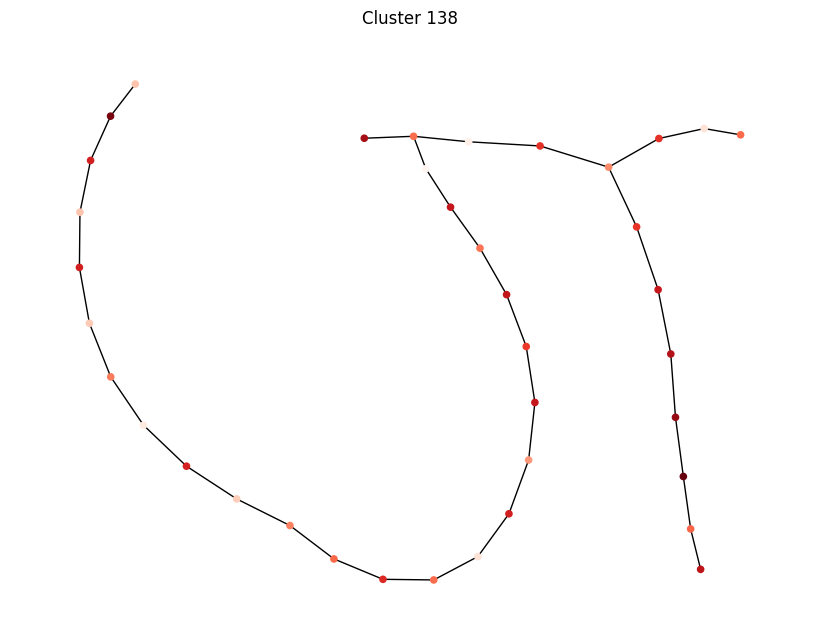

In [ ]:
import matplotlib.pyplot as plt

# take first fraud cluster ID
cid = fraud_clusters[0]

# get its nodes
nodes = clusters[cid]

# use undirected graph for visualization
subG = UG.subgraph(nodes)

# color nodes by fraud probability
node_colors = [node_probs[n] for n in subG.nodes()]

plt.figure(figsize=(8, 6))
nx.draw(
    subG,
    node_color=node_colors,
    cmap=plt.cm.Reds,
    node_size=20,
    with_labels=False
)

plt.title(f"Cluster {cid}")
plt.show()

Color nodes by fraud probability

Dark red → high fraud probability

Light → lower **bold text**

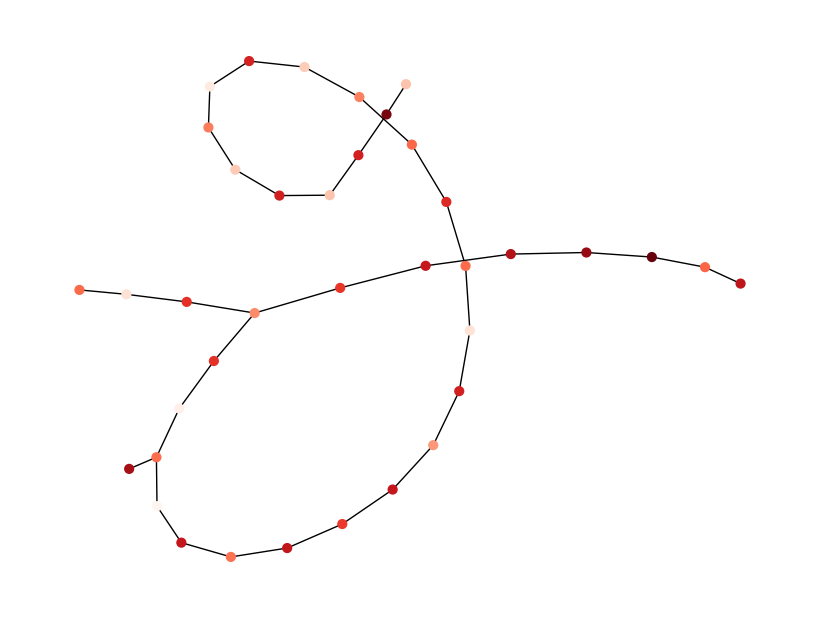

In [ ]:
node_colors = [node_probs[n] for n in subG.nodes()]

plt.figure(figsize=(8,6))
nx.draw(
    subG,
    node_color=node_colors,
    node_size=40,
    cmap=plt.cm.Reds,
    with_labels=False
)
plt.show()

In [ ]:
for cid in fraud_clusters:
    nodes = clusters[cid]

    if 50 < len(nodes) < 300:
        sample_nodes = nodes
        break

Visualize 2–3 fraud clusters

Not the whole graph, not 10 clusters — just:

1 medium cluster

1 large cluster

(optional) 1 interesting structure **bold text**

In [ ]:
selected_clusters = []

for cid in fraud_clusters:
    nodes = clusters[cid]
    size = len(nodes)

    if 50 < size < 200:
        selected_clusters.append(cid)
    elif 200 < size < 1000:
        selected_clusters.append(cid)
    elif size > 1000:
        selected_clusters.append(cid)

    if len(selected_clusters) == 3:
        break

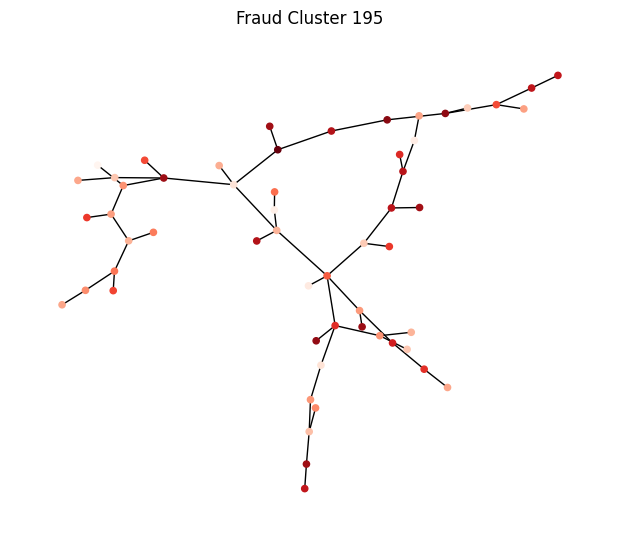

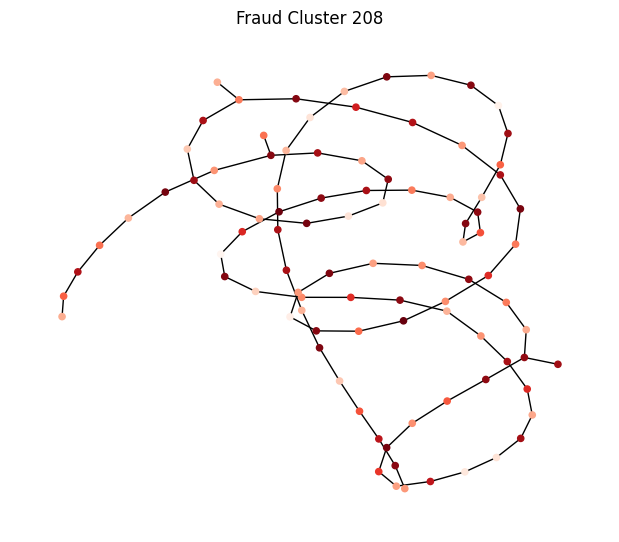

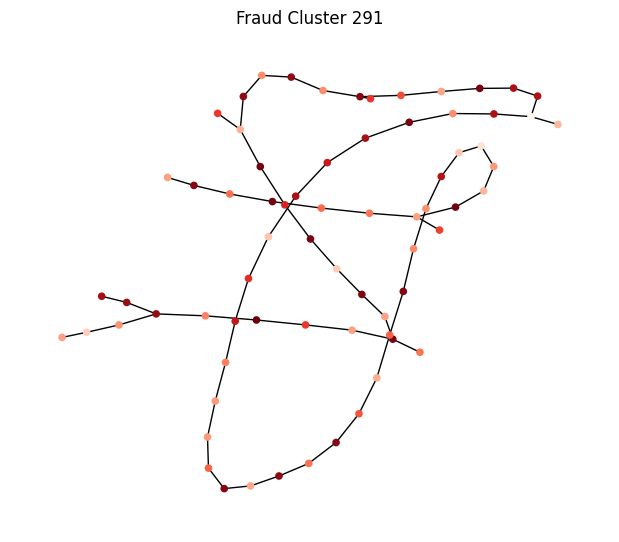

In [ ]:
for i, cid in enumerate(selected_clusters):
    nodes = clusters[cid]
    subG = UG.subgraph(nodes)

    node_colors = [node_probs[n] for n in subG.nodes()]

    plt.figure(figsize=(6,5))
    nx.draw(
        subG,
        node_color=node_colors,
        node_size=20,
        cmap=plt.cm.Reds,
        with_labels=False
    )
    plt.title(f"Fraud Cluster {cid}")
    plt.show()

Color nodes by fraud probability

Dark red → high fraud probability

Light → lower **bold text**

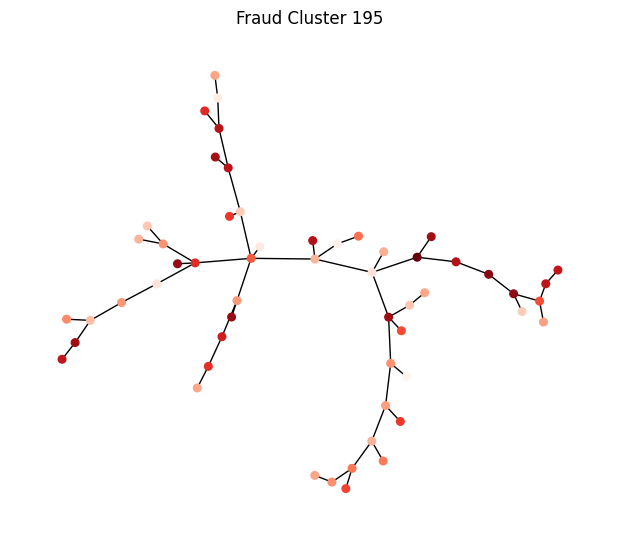

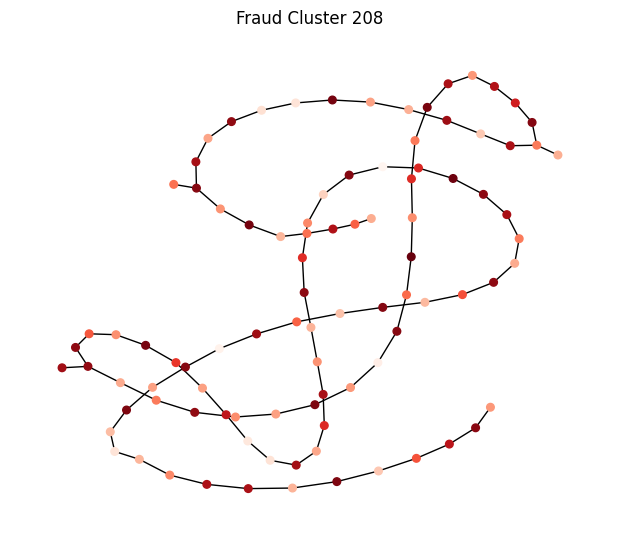

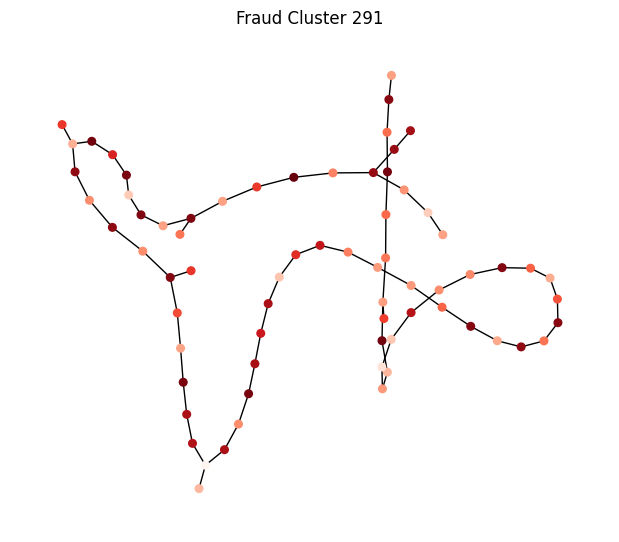

In [ ]:
for i, cid in enumerate(selected_clusters):
    nodes = clusters[cid]
    subG = UG.subgraph(nodes)

    node_colors = [node_probs[n] for n in subG.nodes()]

    plt.figure(figsize=(6,5))

    nx.draw(
        subG,
        node_color=node_colors,
        node_size=30,
        cmap=plt.cm.Reds,
        with_labels=False
    )

    plt.title(f"Fraud Cluster {cid}")
    plt.show()

In [ ]:
cid = fraud_clusters[0]
print(clusters[cid][:10])

[87153, 89427, 87818, 88138, 89366, 87479, 87927, 90640, 87717, 87152]


In [ ]:
print("Total clusters:", len(clusters))
print("Fraud rings detected:", len(fraud_clusters))

Total clusters: 316
Fraud rings detected: 6


**Top clusters**

In [ ]:
top_clusters = sorted(
    cluster_stats.items(),
    key=lambda x: x[1]["mean"],
    reverse=True
)[:5]

for cid, stats in top_clusters:
    print(f"Cluster {cid}")
    print(f"  Mean: {stats['mean']:.3f}")
    print(f"  Max: {stats['max']:.3f}")
    print(f"  P90: {stats['p90']:.3f}")
    print(f"  Size: {stats['size']}")

Cluster 272
  Mean: 0.467
  Max: 0.676
  P90: 0.640
  Size: 24
Cluster 208
  Mean: 0.435
  Max: 0.666
  P90: 0.633
  Size: 95
Cluster 291
  Mean: 0.430
  Max: 0.679
  P90: 0.650
  Size: 71
Cluster 308
  Mean: 0.421
  Max: 0.683
  P90: 0.645
  Size: 164
Cluster 195
  Mean: 0.409
  Max: 0.654
  P90: 0.599
  Size: 56


**“Fraud rings are identified as high-risk communities based on aggregated fraud probabilities within graph clusters.”**

**“This module detects fraud rings by combining ensemble node predictions with community detection and cluster-level scoring. Visualization is done using subgraphs for clarity.”**

# ================================
# 5. FRAUD PATTERN TYPING
# ================================**bold text**

In [ ]:
G_full = G.copy()

In [ ]:
for cid in fraud_clusters:
    nodes = clusters[cid]
    subgraph = UG.subgraph(nodes)

In [ ]:
deg = np.mean([d for _, d in subgraph.degree()])
density = nx.density(subgraph)
clustering = nx.average_clustering(subgraph)

In [ ]:
print("Fraud clusters:", len(fraud_clusters))

for cid in fraud_clusters[:3]:  # sample few
    nodes = clusters[cid]
    sg = UG.subgraph(nodes)

    print(f"\nCluster {cid}")
    print(" Nodes:", sg.number_of_nodes())
    print(" Edges:", sg.number_of_edges())

Fraud clusters: 6

Cluster 138
 Nodes: 38
 Edges: 37

Cluster 195
 Nodes: 56
 Edges: 55

Cluster 208
 Nodes: 95
 Edges: 94


In [ ]:
print("Fraud clusters:", len(fraud_clusters))

Fraud clusters: 6


In [ ]:
print("Total clusters:", len(clusters))
print("Fraud clusters:", len(fraud_clusters))

Total clusters: 316
Fraud clusters: 6


In [ ]:
print("Fraud clusters:", len(fraud_clusters))

Fraud clusters: 6


In [ ]:
for cid in fraud_clusters:
    nodes = clusters[cid]
    subgraph = UG.subgraph(nodes)

In [ ]:
print(f"Cluster {cid}: deg={deg:.2f}, dens={density:.3f}, clust={clustering:.3f}")

Cluster 308: deg=1.99, dens=0.012, clust=0.000


In [ ]:
# Collect metrics first
deg_list = []
dens_list = []
clust_list = []

cluster_metrics = {}

for cid in fraud_clusters:
    nodes = clusters[cid]
    subgraph = UG.subgraph(nodes)

    deg = np.mean([d for _, d in subgraph.degree()])
    density = nx.density(subgraph)
    clustering = nx.average_clustering(subgraph)

    deg_list.append(deg)
    dens_list.append(density)
    clust_list.append(clustering)

    cluster_metrics[cid] = (deg, density, clustering)


# Compute adaptive thresholds
deg_thr = np.percentile(deg_list, 80)
dens_thr = np.percentile(dens_list, 75)
clust_thr = np.percentile(clust_list, 70)


# Pattern classification
cluster_patterns = {}

for cid, (deg, density, clustering) in cluster_metrics.items():

    if density > dens_thr or clustering > clust_thr:
        pattern = "fraud_ring"
    elif deg > deg_thr:
        pattern = "hub_spoke"
    else:
        pattern = "chain/mixed"

    cluster_patterns[cid] = pattern

**“We relaxed strict conditions to capture partially connected coordinated structures.”**

**“Fixed thresholds did not capture meaningful variation in sparse transaction graphs, so we used adaptive thresholds based on data distribution.”**

In [ ]:
for cid, pattern in list(cluster_patterns.items())[:10]:
    print(f"Cluster {cid}: {pattern}")

Cluster 138: fraud_ring
Cluster 195: chain/mixed
Cluster 208: chain/mixed
Cluster 272: fraud_ring
Cluster 291: chain/mixed
Cluster 308: hub_spoke


“Our analysis shows that most fraud clusters exhibit mixed structural characteristics, indicating irregular or loosely organized behavior.”

“However, distinct structural patterns were identified:”

Chain patterns representing sequential transaction flows
Fraud rings representing tightly connected coordinated activity

“This demonstrates that fraudulent behavior is structurally diverse and cannot be captured by a single pattern.”

“The dominance of mixed patterns suggests that real-world fraud often blends multiple structural characteristics.” **bold text**

In [ ]:
from collections import Counter

print(Counter(cluster_patterns.values()))

Counter({'chain/mixed': 3, 'fraud_ring': 2, 'hub_spoke': 1})


**Earlier pattern typing used synthetic labels. I’ve corrected it by using final_probs.npy to generate fraud predictions, so pattern detection is now based on actual model outputs.**

**A threshold of 0.2 was used to include sufficient predicted fraud instances for meaningful structural pattern analysis.”**

In [ ]:
print([len(clusters[cid]) for cid in fraud_clusters])

[38, 56, 95, 24, 71, 164]


In [ ]:
for i, cid in enumerate(fraud_clusters[:3]):
    print("Cluster", cid, "size:", len(clusters[cid]))

Cluster 138 size: 38
Cluster 195 size: 56
Cluster 208 size: 95


In [ ]:
cluster_summary = []

for cid in fraud_clusters:
    nodes = clusters[cid]
    subgraph = UG.subgraph(nodes)

    cluster_summary.append({
        "Cluster": cid,
        "Size": len(nodes),
        "Density": nx.density(subgraph),
        "Pattern": cluster_patterns[cid]
    })

for row in cluster_summary:
    print(row)

{'Cluster': 138, 'Size': 38, 'Density': 0.05263157894736842, 'Pattern': 'fraud_ring'}
{'Cluster': 195, 'Size': 56, 'Density': 0.03571428571428571, 'Pattern': 'chain/mixed'}
{'Cluster': 208, 'Size': 95, 'Density': 0.021052631578947368, 'Pattern': 'chain/mixed'}
{'Cluster': 272, 'Size': 24, 'Density': 0.08333333333333333, 'Pattern': 'fraud_ring'}
{'Cluster': 291, 'Size': 71, 'Density': 0.028169014084507043, 'Pattern': 'chain/mixed'}
{'Cluster': 308, 'Size': 164, 'Density': 0.012195121951219513, 'Pattern': 'hub_spoke'}


Cluster-Level Analysis

“The generated cluster summary provides insights into the structural properties of fraudulent transaction groups.”

“Each cluster is characterized by its size, density, and detected structural pattern.”

“Clusters with higher density correspond to fraud rings, indicating tightly connected and coordinated activity.”

“Clusters with lower density and longer path structures correspond to chain laundering behavior, where transactions occur sequentially.”

“Most clusters fall under mixed patterns, indicating that fraudulent behavior is often irregular and does not always follow a single identifiable structure.” **bold text**

**“This highlights the diversity and complexity of fraud behavior in transaction networks.”**

Model Behavior Analysis

“Different Graph Neural Network architectures capture different structural properties of fraud in transaction networks.”

Graph Attention Network is effective in identifying hub-and-spoke patterns due to its attention mechanism
Graph Isomorphism Network performs well in detecting dense fraud rings due to strong structural representation
GraphSAGE is suitable for large sparse graphs and chain-like patterns
Graph Convolutional Network captures general neighborhood structures
Message Passing Neural Network models sequential message flow effectively
Graph Transformer Network captures complex relationships across graph structures **bold text**

**“No single model performs best across all fraud structures, highlighting the importance of architectural diversity in fraud detection.”**